In [1]:
# -*- coding: utf-8 -*-
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from time import time
import warnings
warnings.filterwarnings('ignore')

# Проверка устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Работаем на: {device}')
print(f'PyTorch: {torch.__version__}')

# Фиксируем random seed для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

Работаем на: cpu
PyTorch: 2.10.0+cpu


In [2]:
# Гиперпараметры
BATCH_SIZE = 64

# Трансформации: нормализуем в диапазон [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Загрузка MNIST
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Тренировочных примеров: {len(train_dataset)}')
print(f'Тестовых примеров: {len(test_dataset)}')
print(f'Форма батча: {next(iter(train_loader))[0].shape}')

Тренировочных примеров: 60000
Тестовых примеров: 10000
Форма батча: torch.Size([64, 1, 28, 28])


In [3]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

# Создаем функцию для получения новой модели (нужно для каждого оптимизатора)
def get_model():
    model = SimpleNN().to(device)
    return model

In [4]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = output.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

In [5]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            total_loss += loss.item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

In [6]:
def run_experiment(optimizer_name, lr, momentum=None):
    print(f'\n🚀 Запускаем {optimizer_name} с lr={lr}')
    model = get_model()
    criterion = nn.CrossEntropyLoss()
    
    # Выбираем оптимизатор
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'SGD+Momentum':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Для записи истории
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'time': []
    }
    
    start_time = time()
    
    for epoch in range(1, 6):  # 5 эпох для быстрого результата
        epoch_start = time()
        
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        test_loss, test_acc = evaluate(model, test_loader, criterion)
        
        epoch_time = time() - epoch_start
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['time'].append(epoch_time)
        
        print(f'Эпоха {epoch}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% | Время: {epoch_time:.2f}с')
    
    total_time = time() - start_time
    print(f'✅ {optimizer_name} завершен за {total_time:.2f}с')
    
    return history, total_time

In [7]:
# Настройки эксперимента
learning_rates = [0.001, 0.01, 0.1]  # Попробуем разные LR
optimizers_to_test = ['SGD', 'SGD+Momentum', 'RMSprop', 'Adam']

# Словарь для результатов
results = {}

# Цикл по всем оптимизаторам и скоростям обучения
for opt in optimizers_to_test:
    for lr in learning_rates:
        key = f'{opt}_lr={lr}'
        print('='*60)
        print(f'ЭКСПЕРИМЕНТ: {key}')
        print('='*60)
        
        history, total_time = run_experiment(opt, lr)
        results[key] = {
            'history': history,
            'total_time': total_time,
            'final_acc': history['test_acc'][-1]
        }

ЭКСПЕРИМЕНТ: SGD_lr=0.001

🚀 Запускаем SGD с lr=0.001


Эпоха 1: Train Loss: 2.2114, Train Acc: 26.75% | Test Acc: 44.03% | Время: 29.14с
Эпоха 2: Train Loss: 1.9288, Train Acc: 53.18% | Test Acc: 64.50% | Время: 29.20с
Эпоха 3: Train Loss: 1.4389, Train Acc: 70.46% | Test Acc: 77.11% | Время: 29.02с
Эпоха 4: Train Loss: 0.9933, Train Acc: 78.36% | Test Acc: 81.75% | Время: 29.04с
Эпоха 5: Train Loss: 0.7517, Train Acc: 82.10% | Test Acc: 83.99% | Время: 29.21с
✅ SGD завершен за 145.61с
ЭКСПЕРИМЕНТ: SGD_lr=0.01

🚀 Запускаем SGD с lr=0.01
Эпоха 1: Train Loss: 1.0185, Train Acc: 74.26% | Test Acc: 87.69% | Время: 28.91с
Эпоха 2: Train Loss: 0.3789, Train Acc: 89.19% | Test Acc: 89.70% | Время: 28.88с
Эпоха 3: Train Loss: 0.3170, Train Acc: 90.85% | Test Acc: 91.72% | Время: 28.96с
Эпоха 4: Train Loss: 0.2841, Train Acc: 91.69% | Test Acc: 92.33% | Время: 29.03с
Эпоха 5: Train Loss: 0.2595, Train Acc: 92.50% | Test Acc: 92.88% | Время: 29.14с
✅ SGD завершен за 144.91с
ЭКСПЕРИМЕНТ: SGD_lr=0.1

🚀 Запускаем SGD с lr=0.1
Эпоха 1: Train Loss: 0.448

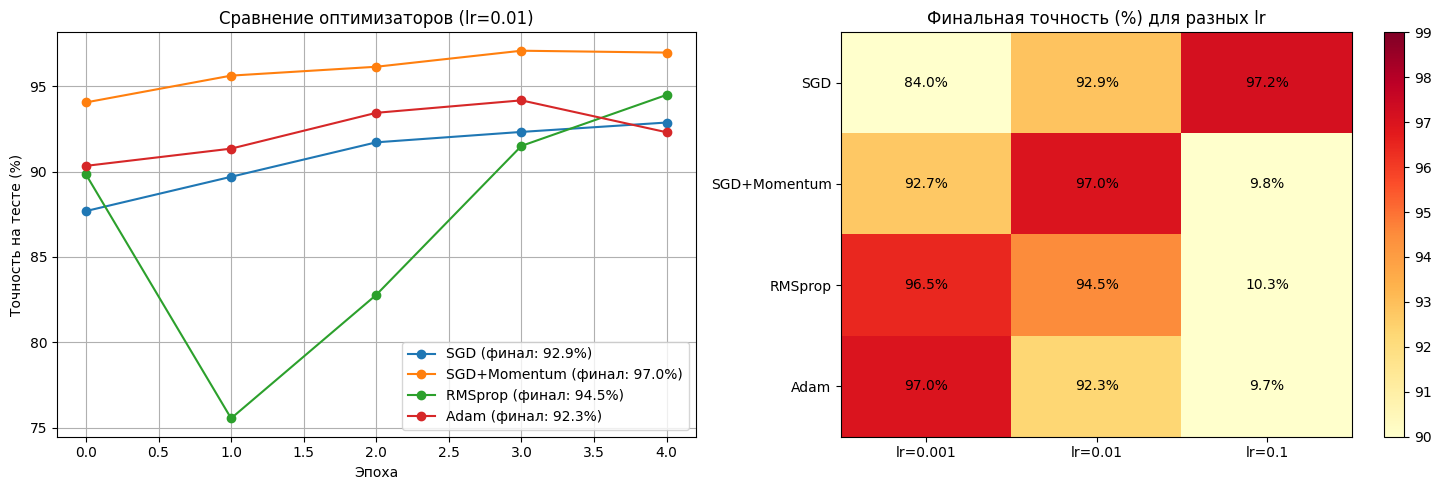

In [8]:
# Сравнение финальной точности
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Сравнение точности для lr=0.01
ax = axes[0]
for opt in optimizers_to_test:
    key = f'{opt}_lr=0.01'
    if key in results:
        ax.plot(results[key]['history']['test_acc'], 'o-', label=f'{opt} (финал: {results[key]["final_acc"]:.1f}%)')
ax.set_xlabel('Эпоха')
ax.set_ylabel('Точность на тесте (%)')
ax.set_title('Сравнение оптимизаторов (lr=0.01)')
ax.legend()
ax.grid(True)

# График 2: Тепловая карта финальной точности для всех LR
lr_values = [0.001, 0.01, 0.1]
acc_matrix = np.zeros((len(optimizers_to_test), len(lr_values)))

for i, opt in enumerate(optimizers_to_test):
    for j, lr in enumerate(lr_values):
        key = f'{opt}_lr={lr}'
        if key in results:
            acc_matrix[i, j] = results[key]['final_acc']

im = axes[1].imshow(acc_matrix, cmap='YlOrRd', aspect='auto', vmin=90, vmax=99)
axes[1].set_xticks(range(len(lr_values)))
axes[1].set_xticklabels([f'lr={lr}' for lr in lr_values])
axes[1].set_yticks(range(len(optimizers_to_test)))
axes[1].set_yticklabels(optimizers_to_test)
axes[1].set_title('Финальная точность (%) для разных lr')

# Добавляем значения в ячейки
for i in range(len(optimizers_to_test)):
    for j in range(len(lr_values)):
        if acc_matrix[i, j] > 0:
            axes[1].text(j, i, f'{acc_matrix[i, j]:.1f}%', ha='center', va='center', color='black')

plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

🏆 ЛУЧШИЙ РЕЗУЛЬТАТ: SGD_lr=0.1
   Финальная точность: 97.17%
   Время обучения: 144.88с


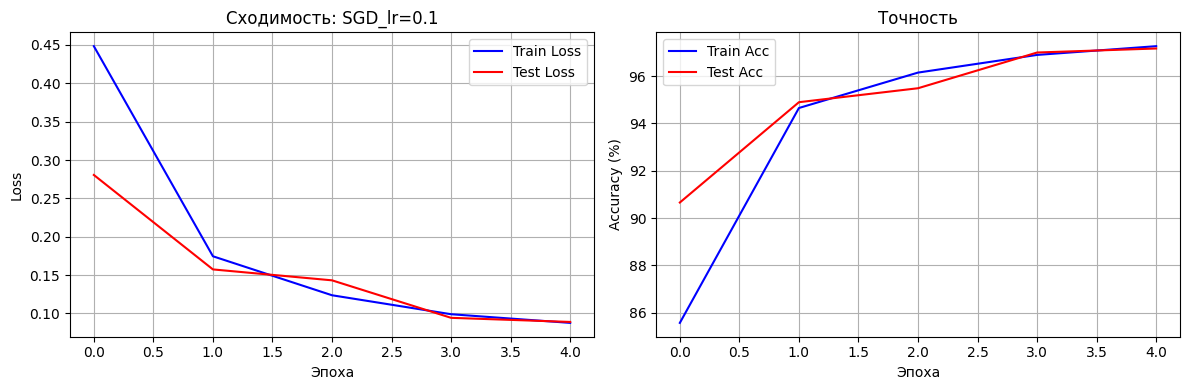

In [9]:
# Находим лучшую комбинацию
best_key = max(results, key=lambda x: results[x]['final_acc'])
best_result = results[best_key]

print(f'🏆 ЛУЧШИЙ РЕЗУЛЬТАТ: {best_key}')
print(f'   Финальная точность: {best_result["final_acc"]:.2f}%')
print(f'   Время обучения: {best_result["total_time"]:.2f}с')

# График сходимости лучшего оптимизатора
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(best_result['history']['train_loss'], 'b-', label='Train Loss')
plt.plot(best_result['history']['test_loss'], 'r-', label='Test Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title(f'Сходимость: {best_key}')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(best_result['history']['train_acc'], 'b-', label='Train Acc')
plt.plot(best_result['history']['test_acc'], 'r-', label='Test Acc')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy (%)')
plt.title('Точность')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()